In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#importing the 2025 csv ttc subway delay data as a pandas dataframe
df_2025 = pd.read_csv('C:/Users/safab/ML7-Project/C8ML7_subwaydelay/data/raw/csv/ttc-subway-delay-data-2025.csv')

#Adding a new column that is a formatted Year Column into data type Date rather than a string
df_2025['Formatted Date'] = pd.to_datetime(df_2025['Date'])

#Extracted Year, Month, and Day from Date
df_2025['Year'] = df_2025['Formatted Date'].dt.year
df_2025['Month'] = df_2025['Formatted Date'].dt.month
df_2025['Day of the Month'] = df_2025['Formatted Date'].dt.day

#Formatted time from string to time and extracting hour of day
df_2025['Formatted Time'] = pd.to_datetime(df_2025['Time'], format='%H:%M').dt.time
df_2025['Hour'] = pd.to_datetime(df_2025['Time'], format='%H:%M').dt.hour 

#dropped preformatted columns, as well columns that are not used such as id and Bound
columns_to_drop = ['id','Date', 'Time', 'Bound']

df = df_2025.drop(columns=columns_to_drop)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25713 entries, 0 to 25712
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Day               25713 non-null  str           
 1   Station           25713 non-null  str           
 2   Code              25713 non-null  str           
 3   Min Delay         25713 non-null  int64         
 4   Min Gap           25713 non-null  int64         
 5   Line              25646 non-null  str           
 6   Vehicle           25713 non-null  int64         
 7   Formatted Date    25713 non-null  datetime64[us]
 8   Year              25713 non-null  int32         
 9   Month             25713 non-null  int32         
 10  Day of the Month  25713 non-null  int32         
 11  Formatted Time    25713 non-null  object        
 12  Hour              25713 non-null  int32         
dtypes: datetime64[us](1), int32(4), int64(3), object(1), str(4)
memory usage: 2.2+ MB


Minute Delay Averge (grouped by month): Month
1     3.032795
2     3.865079
3     3.176322
4     2.860179
5     2.499770
6     2.637629
7     2.638850
8     1.887008
9     2.307565
10    2.540701
11    2.802083
12    2.880464
Name: Min Delay, dtype: float64



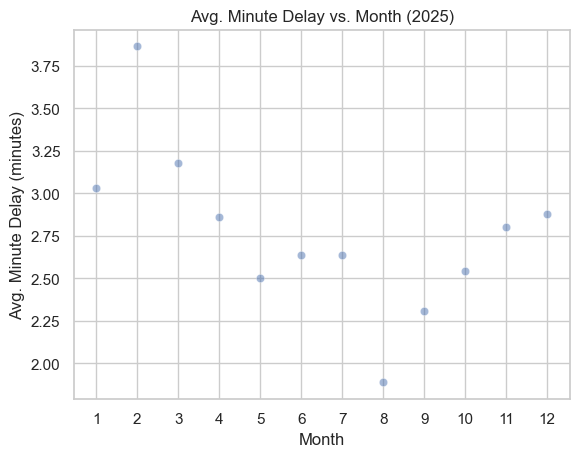

In [6]:
import seaborn as sns

# This code will aim to try and calculate the average min delay per month in 2025 and plot the results

# Set a clean visual style for plot using seaborn instead of .scatter from matplotlib
sns.set_theme(style="whitegrid")


daily_avg_groupby = df_2025.groupby(df_2025['Month'])['Min Delay'].mean()
print(f"Minute Delay Averge (grouped by month): {df_2025.groupby(df_2025['Month'])['Min Delay'].mean()}\n")
#print(f"Minute Delay Median (grouped by month): {df_2025.groupby(df_2025['Month'])['Min Delay'].median()}")

#Plotting Average Delay Time vs Month with raw uneditted data
plt.xlabel('Month')
plt.ylabel('Avg. Minute Delay (minutes)')
plt.xticks(df_2025['Month'].unique())
plt.title('Avg. Minute Delay vs. Month (2025)')
#plt.scatter((df_2025['Month'].unique()), daily_avg_groupby, s=5)
sns.scatterplot(x=df_2025['Month'].unique(), y=daily_avg_groupby, alpha=0.5)

plt.show()


Min Delay Averge (grouped by Day of week): <StringArray>
['Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday']
Length: 7, dtype: str


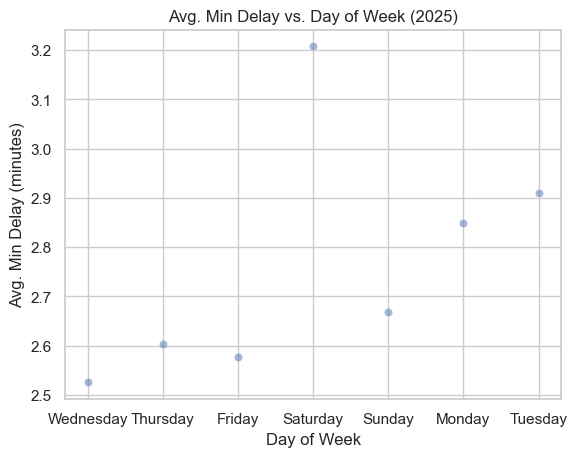

In [5]:
import seaborn as sns

# This code will aim to try and calculate the average min delay per day of the week in 2025

dayofweek_avg_groupby = df_2025.groupby(df_2025['Day'])['Min Delay'].mean()
print(f"Min Delay Averge (grouped by Day of week): {df_2025['Day'].unique()}")

# Set a clean visual style for plot using seaborn instead of .scatter from matplotlib
sns.set_theme(style="whitegrid")

#Plotting Average Delay Time vs Month with raw uneditted data
sns.scatterplot(x=df_2025['Day'].unique(), y=dayofweek_avg_groupby, alpha=0.5)
plt.xlabel('Day of Week')
plt.ylabel('Avg. Min Delay (minutes)')
plt.title('Avg. Min Delay vs. Day of Week (2025)')
#plt.scatter((df_2025['Day'].unique()), dayofweek_avg_groupby, s=7)
#plt.grid(True)
plt.show()

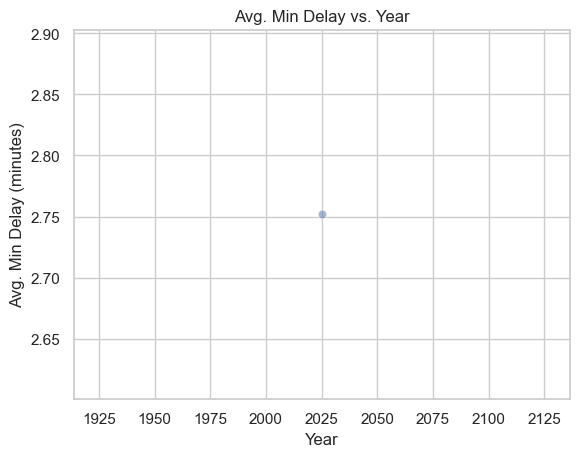

In [8]:
import seaborn as sns

# This code will aim to try and calculate the average min delay per day of the week in 2025

year_avg_groupby = df_2025.groupby(df_2025['Year'])['Min Delay'].mean()
#print(f"Min Delay Averge (grouped by Day of week): {df_2025['Day'].unique()}")

# Set a clean visual style for plot using seaborn instead of .scatter from matplotlib
sns.set_theme(style="whitegrid")

#Plotting Average Delay Time vs Month with raw uneditted data
sns.scatterplot(x=df_2025['Year'].unique(), y=year_avg_groupby, alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Avg. Min Delay (minutes)')
plt.title('Avg. Min Delay vs. Year')
#plt.scatter((df_2025['Day'].unique()), dayofweek_avg_groupby, s=7)
#plt.grid(True)
plt.show()

In [7]:
#This code aims to showcase the top5 stations with the highest tot+

# Filter only rows with actual delays
delays_df = df_2025[df_2025["Min Delay"] > 0].copy()
#delays_df = df

# Group by station and calculate delay metrics
station_delay_summary = delays_df.groupby("Station").agg(
    Total_Incidents=("Min Delay", "count"),
    Total_Min_Delay=("Min Delay", "sum"),
    Avg_Delay_Per_Incident=("Min Delay", "mean")
).sort_values(by="Total_Incidents", ascending=False)

#Round average delay
station_delay_summary["Avg_Delay_Per_Incident"] = station_delay_summary["Avg_Delay_Per_Incident"].round(2)

#Display top 5 stations with most delay incidents
station_delay_summary.head(5)

,Total_Incidents,Total_Min_Delay,Avg_Delay_Per_Incident
Station,,,
WILSON STATION,369,2198,5.96
KIPLING STATION,360,2281,6.34
KENNEDY BD STATION,346,2232,6.45
FINCH STATION,315,1826,5.80
BLOOR STATION,288,1783,6.19


Available station names (sample): ['WILSON STATION', 'KIPLING STATION', 'KENNEDY BD STATION', 'FINCH STATION', 'BLOOR STATION', 'EGLINTON STATION', 'DAVISVILLE STATION', 'WARDEN STATION', 'UNION STATION', 'YONGE BD STATION']


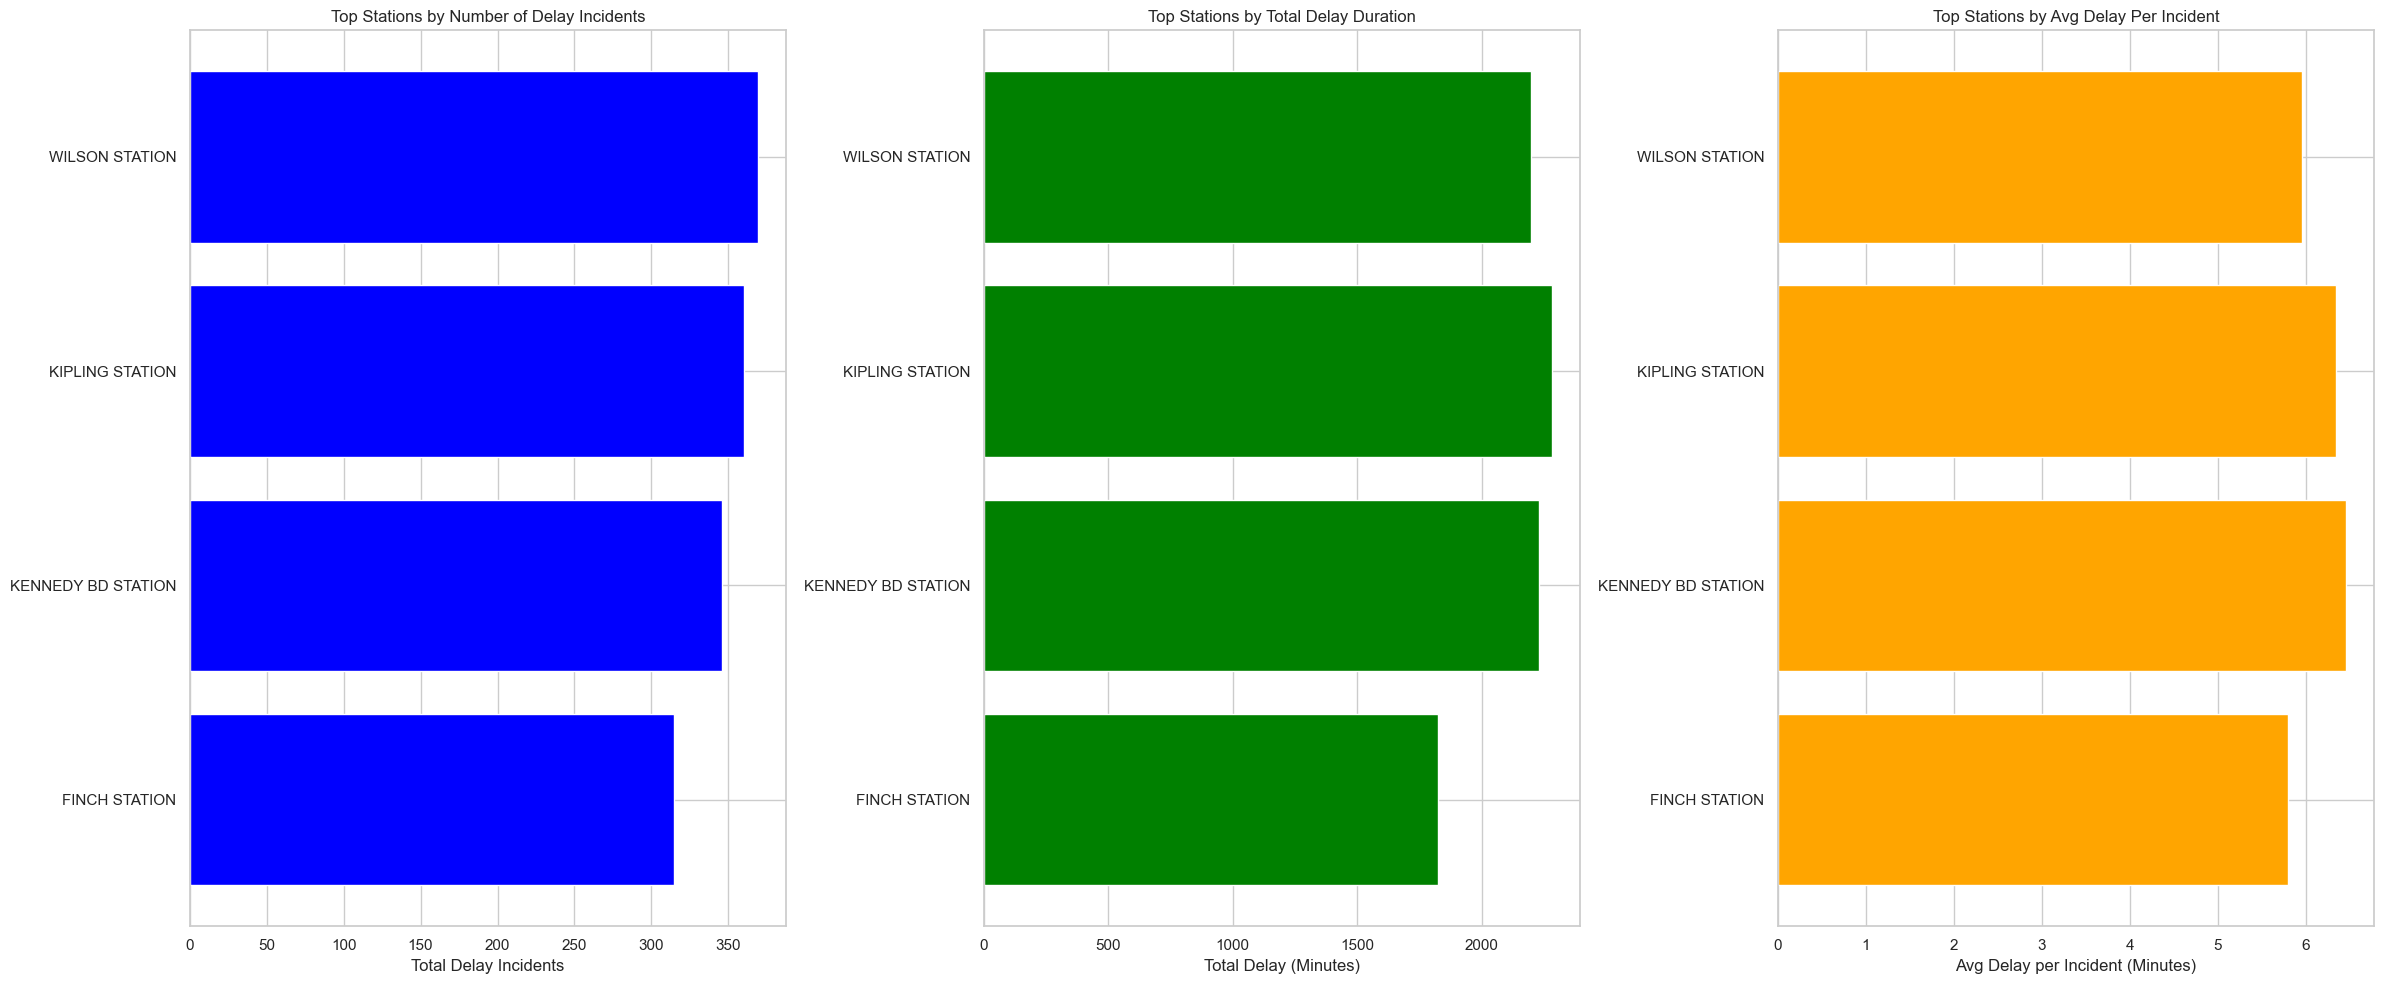

In [12]:
# Step 1: Get top 5 stations by Total_Incidents
top_stations = station_delay_summary.sort_values(by="Total_Incidents", ascending=False).head(4)

# Step 2: Check UNION STATION's presence and spelling
print("Available station names (sample):", station_delay_summary.index.tolist()[:10])  # See what's in the index


# Step 4: Plotting
fig, axes = plt.subplots(1, 3, figsize=(24, 10))
stations_reversed = top_stations.index[::-1]

# Total Incidents
axes[0].barh(stations_reversed, top_stations.loc[stations_reversed]["Total_Incidents"], color='blue')
axes[0].set_xlabel("Total Delay Incidents")
axes[0].set_title("Top Stations by Number of Delay Incidents")

# Total Delay
axes[1].barh(stations_reversed, top_stations.loc[stations_reversed]["Total_Min_Delay"], color='green')
axes[1].set_xlabel("Total Delay (Minutes)")
axes[1].set_title("Top Stations by Total Delay Duration")

# Avg Delay
axes[2].barh(stations_reversed, top_stations.loc[stations_reversed]["Avg_Delay_Per_Incident"], color='orange')
axes[2].set_xlabel("Avg Delay per Incident (Minutes)")
axes[2].set_title("Top Stations by Avg Delay Per Incident")


# Save before showing
plt.tight_layout()
plt.savefig("top_stations_with_delays.png", dpi=300, bbox_inches='tight')  # Save first
plt.show()  # Then show